In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

plt.rcParams["figure.figsize"] = (12,6)

In [4]:
import pandas as pd

nav = pd.read_csv("../data/raw/02_nav_history.csv")

nav["date"] = pd.to_datetime(nav["date"])

print(nav.head())
print(nav.info())

   amfi_code       date      nav
0     119551 2022-01-03  54.3856
1     119551 2022-01-04  54.3474
2     119551 2022-01-05  54.6869
3     119551 2022-01-06  55.4550
4     119551 2022-01-07  55.3692
<class 'pandas.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   amfi_code  46000 non-null  int64         
 1   date       46000 non-null  datetime64[us]
 2   nav        46000 non-null  float64       
dtypes: datetime64[us](1), float64(1), int64(1)
memory usage: 1.1 MB
None


In [5]:
fig = px.line(
    nav,
    x="date",
    y="nav",
    color="amfi_code",
    title="Daily NAV Trend of All Mutual Fund Schemes (2022–2026)"
)

# Highlight 2023 Bull Run
fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    fillcolor="green",
    opacity=0.15,
    annotation_text="2023 Bull Run",
    line_width=0
)

# Highlight 2024 Market Correction
fig.add_vrect(
    x0="2024-01-01",
    x1="2024-12-31",
    fillcolor="red",
    opacity=0.15,
    annotation_text="2024 Market Correction",
    line_width=0
)

fig.show()

In [6]:
fig.write_image("../charts/nav_trend.png")

## Insight 1

Daily NAV showed an overall upward trend from 2022–2026. The 2023 bull run resulted in strong NAV appreciation across most schemes, while 2024 experienced visible market corrections.

In [8]:
import pandas as pd

fund = pd.read_csv("../data/raw/01_fund_master.csv")
nav = pd.read_csv("../data/raw/02_nav_history.csv")
aum = pd.read_csv("../data/raw/03_aum_by_fund_house.csv")
sip = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")
category = pd.read_csv("../data/raw/05_category_inflows.csv")
folio = pd.read_csv("../data/raw/06_industry_folio_count.csv")
performance = pd.read_csv("../data/raw/07_scheme_performance.csv")
transactions = pd.read_csv("../data/raw/08_investor_transactions.csv")
portfolio = pd.read_csv("../data/raw/09_portfolio_holdings.csv")
benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

print("All datasets loaded successfully!")

All datasets loaded successfully!


In [9]:
print(aum.columns)

Index(['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes'], dtype='str')


In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

aum["date"] = pd.to_datetime(aum["date"])
aum["year"] = aum["date"].dt.year

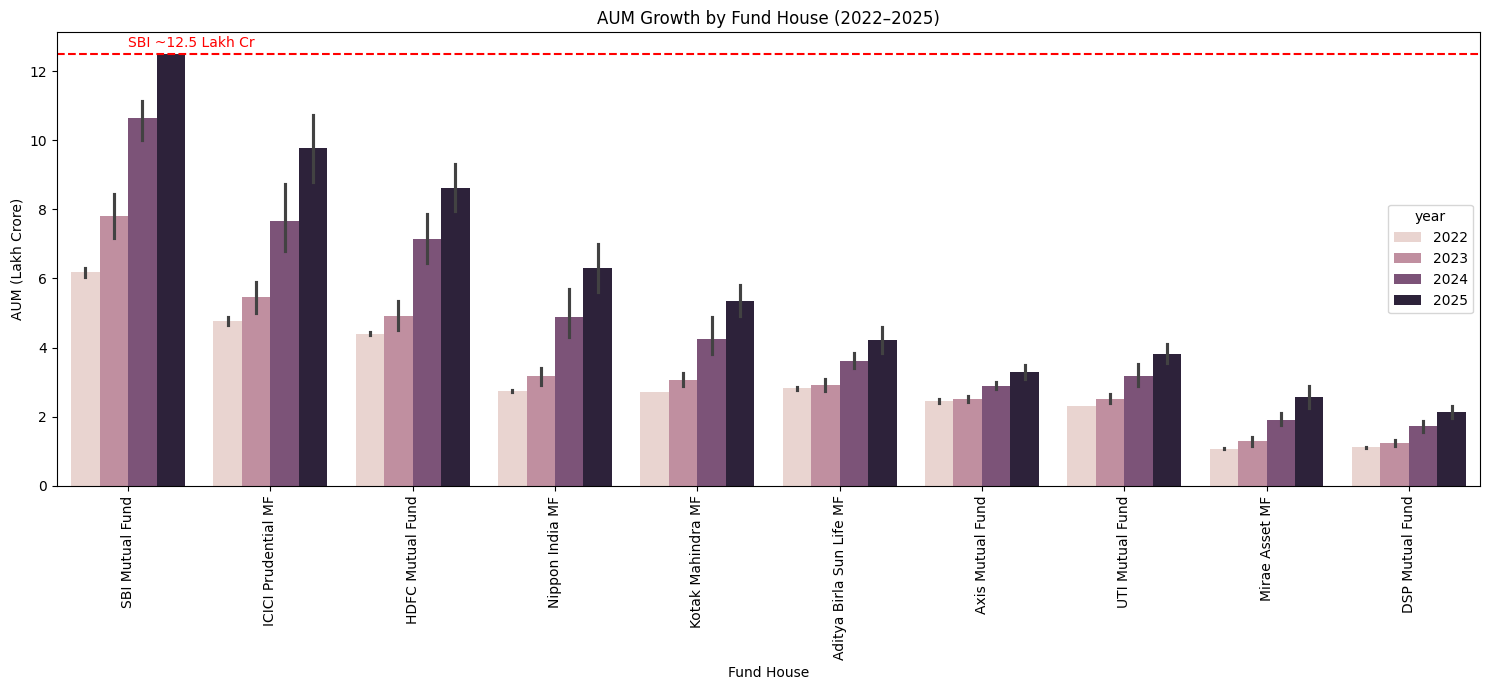

In [12]:
plt.figure(figsize=(15,7))

sns.barplot(
    data=aum,
    x="fund_house",
    y="aum_lakh_crore",
    hue="year"
)

plt.xticks(rotation=90)
plt.title("AUM Growth by Fund House (2022–2025)")
plt.xlabel("Fund House")
plt.ylabel("AUM (Lakh Crore)")
plt.tight_layout()
plt.axhline(12.5, color="red", linestyle="--")
plt.text(
    0,
    12.7,
    "SBI ~12.5 Lakh Cr",
    color="red",
    fontsize=10
)
plt.savefig("../charts/aum_growth.png", dpi=300)

plt.show()

## Insight 2

SBI Mutual Fund consistently maintained the highest Assets Under Management (AUM), reaching approximately ₹12.5 lakh crore, indicating its dominant position among fund houses.

In [13]:
print(sip.columns)

Index(['month', 'sip_inflow_crore', 'active_sip_accounts_crore',
       'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct'],
      dtype='str')


In [14]:
import plotly.express as px
import pandas as pd

sip["month"] = pd.to_datetime(sip["month"])

In [15]:
fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    markers=True,
    title="Monthly SIP Inflow Trend (Jan 2022 – Dec 2025)"
)

fig.show()

In [18]:
max_row = sip.loc[sip["sip_inflow_crore"].idxmax()]

fig.add_annotation(
    x=max_row["month"].strftime("%Y-%m-%d"),
    y=max_row["sip_inflow_crore"],
    text=f"All-Time High<br>₹{max_row['sip_inflow_crore']:.0f} Cr",
    showarrow=True,
    arrowhead=2
)

fig.show()

In [25]:
import plotly.io as pio
print(pio.kaleido.scope)

In [23]:
import plotly
print(plotly.__version__)

6.8.0


In [26]:
plt.savefig("../charts/chart_name.png", dpi=300, bbox_inches="tight")

<Figure size 1200x600 with 0 Axes>

## Insight 3

Monthly SIP inflows increased steadily from 2022 to 2025, reaching their highest value in December 2025, indicating growing investor confidence and increasing participation in mutual fund SIP investments.

In [27]:
print(category.columns)

Index(['month', 'category', 'net_inflow_crore'], dtype='str')


In [28]:
category["month"] = pd.to_datetime(category["month"])

In [29]:
heatmap_data = category.pivot_table(
    index="category",
    columns="month",
    values="net_inflow_crore",
    aggfunc="sum"
)

heatmap_data.head()

month,2024-04-01,2024-05-01,2024-06-01,2024-07-01,2024-08-01,2024-09-01,2024-10-01,2024-11-01,2024-12-01,2025-01-01,2025-02-01,2025-03-01
category,,,,,,,,,,,,
ELSS,466.0,553.0,472.0,471.0,499.0,537.0,537.0,571.0,521.0,516.0,437.0,500.0
Flexi Cap,4947.0,5529.0,4478.0,4869.0,5562.0,5397.0,6004.0,6111.0,4654.0,5603.0,6068.0,4767.0
Gilt,784.0,836.0,864.0,959.0,952.0,925.0,898.0,704.0,831.0,744.0,942.0,956.0
Hybrid,2955.0,3487.0,3163.0,3291.0,3684.0,3015.0,3314.0,3264.0,3538.0,2967.0,3360.0,2830.0
Large & Mid Cap,4214.0,4368.0,4610.0,5023.0,5411.0,4528.0,4581.0,5556.0,4878.0,4816.0,5524.0,4243.0


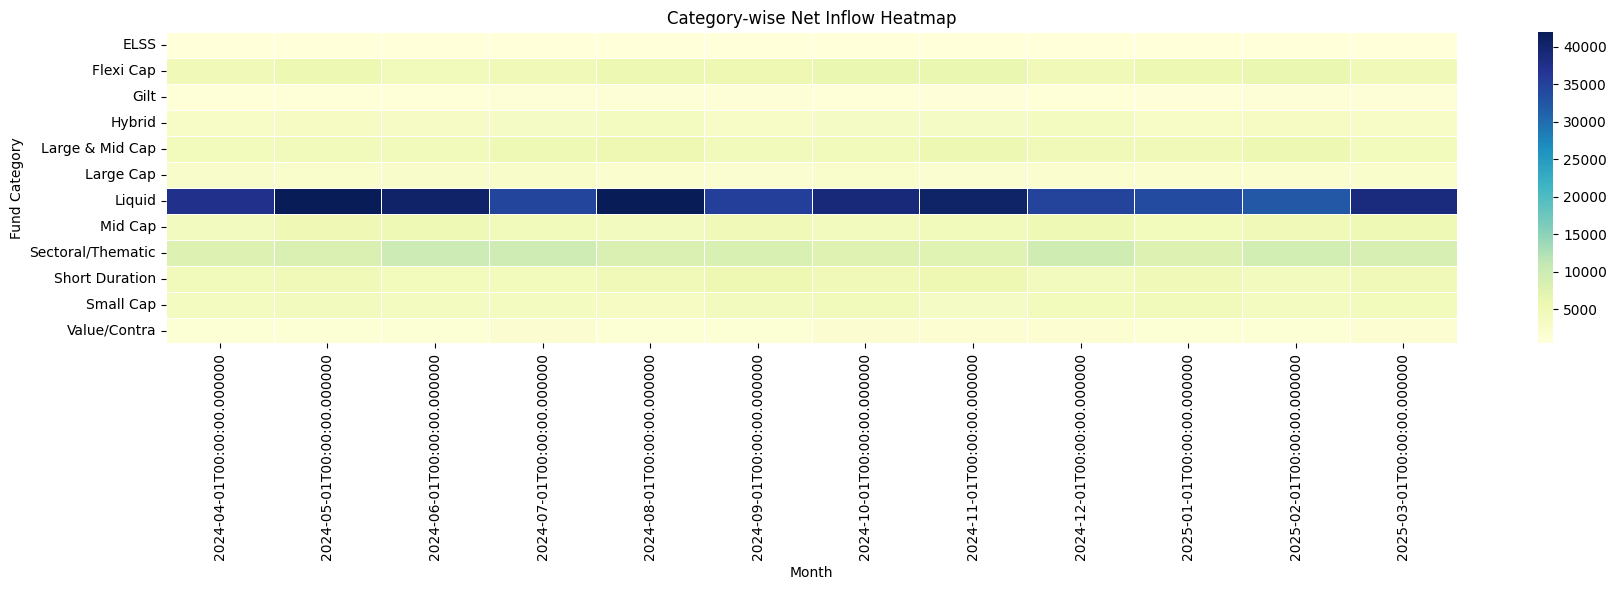

In [30]:
plt.figure(figsize=(18,6))

sns.heatmap(
    heatmap_data,
    cmap="YlGnBu",
    linewidths=0.5
)

plt.title("Category-wise Net Inflow Heatmap")
plt.xlabel("Month")
plt.ylabel("Fund Category")

plt.tight_layout()

plt.savefig("../charts/category_heatmap.png", dpi=300)

plt.show()

## Insight 4

Equity-oriented categories consistently attracted higher net inflows than debt categories across most months, reflecting stronger investor preference for equity mutual funds.

In [31]:
print(transactions.columns)

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='str')


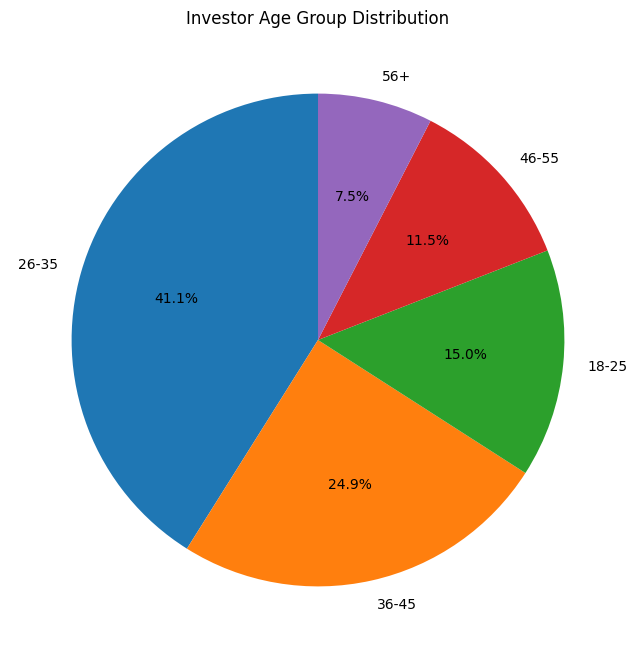

In [32]:
plt.figure(figsize=(8,8))

transactions["age_group"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Investor Age Group Distribution")
plt.ylabel("")

plt.savefig("../charts/age_group_distribution.png", dpi=300, bbox_inches="tight")

plt.show()

## Insight 5

The majority of mutual fund investors belong to the dominant age group, indicating that investing is concentrated among working-age individuals.

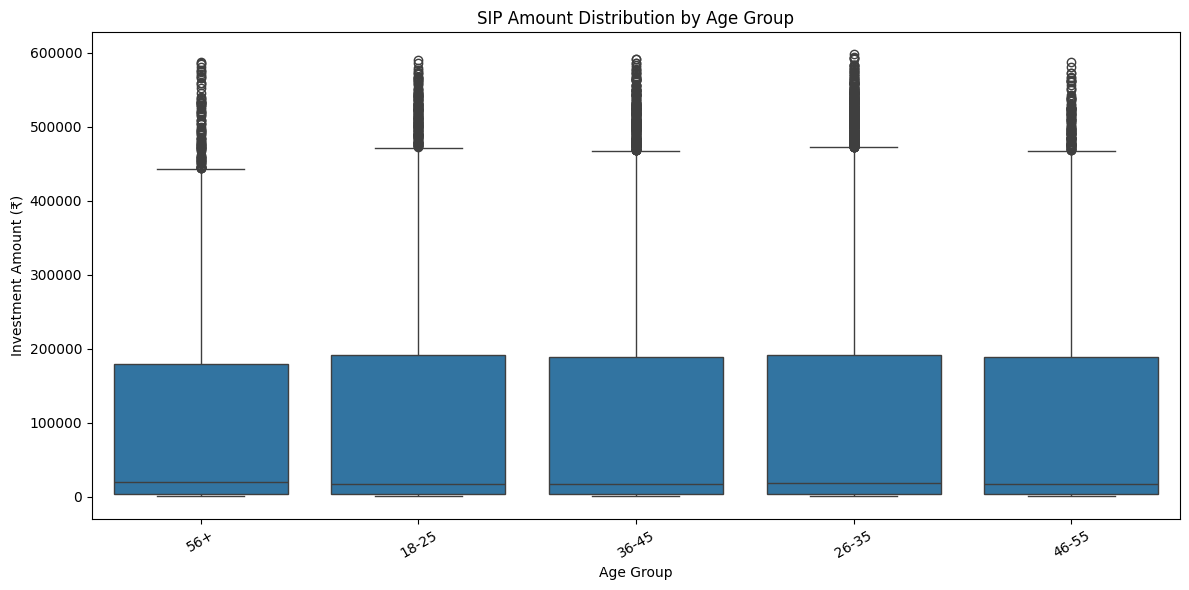

In [33]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=transactions,
    x="age_group",
    y="amount_inr"
)

plt.title("SIP Amount Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Investment Amount (₹)")

plt.xticks(rotation=30)

plt.tight_layout()

plt.savefig("../charts/sip_boxplot_age.png", dpi=300, bbox_inches="tight")

plt.show()

## Insight 6

Investment amounts vary across age groups, with some groups showing a wider spread and higher-value investments.

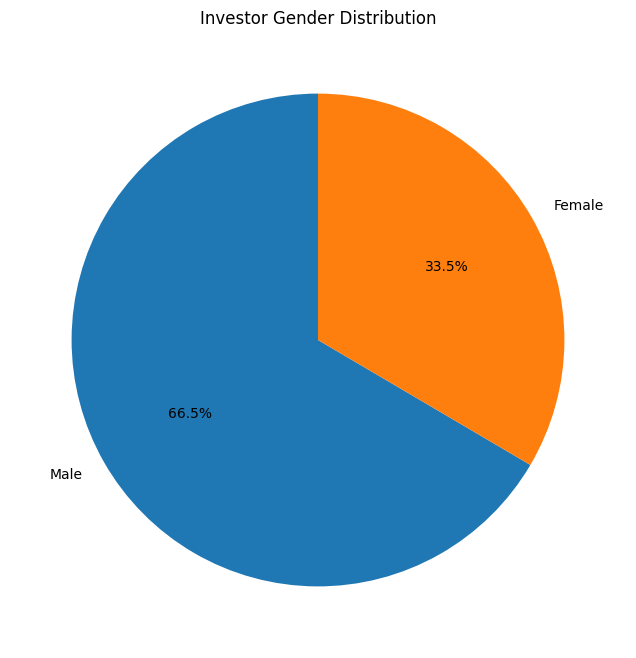

In [34]:
plt.figure(figsize=(8,8))

transactions["gender"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Investor Gender Distribution")
plt.ylabel("")

plt.savefig("../charts/gender_distribution.png", dpi=300, bbox_inches="tight")

plt.show()

## Insight 7

The investor base shows a noticeable gender distribution, highlighting participation patterns across different genders.

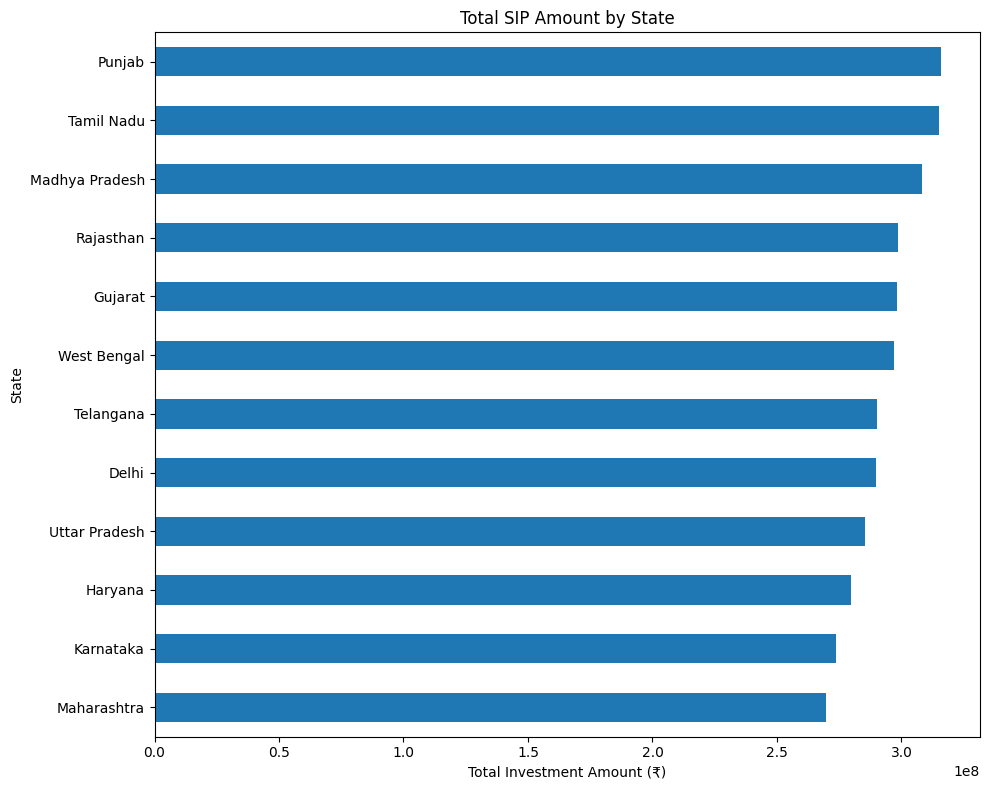

In [35]:
state_data = transactions.groupby("state")["amount_inr"].sum().sort_values()

plt.figure(figsize=(10,8))

state_data.plot(kind="barh")

plt.title("Total SIP Amount by State")
plt.xlabel("Total Investment Amount (₹)")
plt.ylabel("State")

plt.tight_layout()

plt.savefig("../charts/state_distribution.png", dpi=300)

plt.show()

## Insight 8

Some states contribute substantially higher SIP investment amounts, indicating stronger mutual fund participation in those regions.

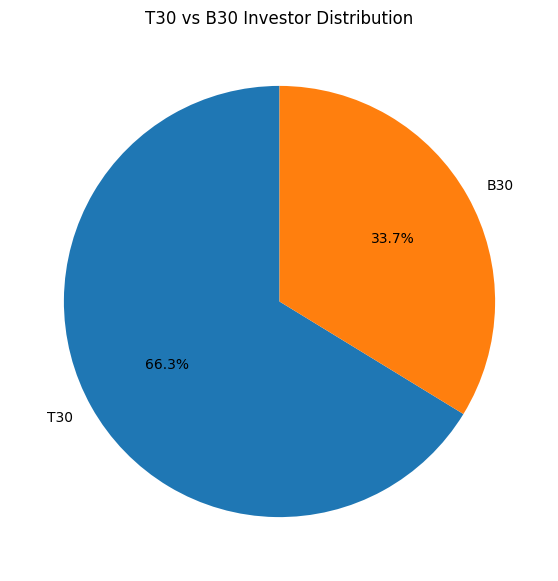

In [36]:
plt.figure(figsize=(7,7))

transactions["city_tier"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.title("T30 vs B30 Investor Distribution")
plt.ylabel("")

plt.savefig("../charts/city_tier_distribution.png", dpi=300)

plt.show()

## Insight 9

T30 cities account for a larger share of investors, while B30 participation continues to grow.

In [37]:
print(folio.columns)

Index(['month', 'total_folios_crore', 'equity_folios_crore',
       'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore'],
      dtype='str')


In [38]:
folio["month"] = pd.to_datetime(folio["month"])

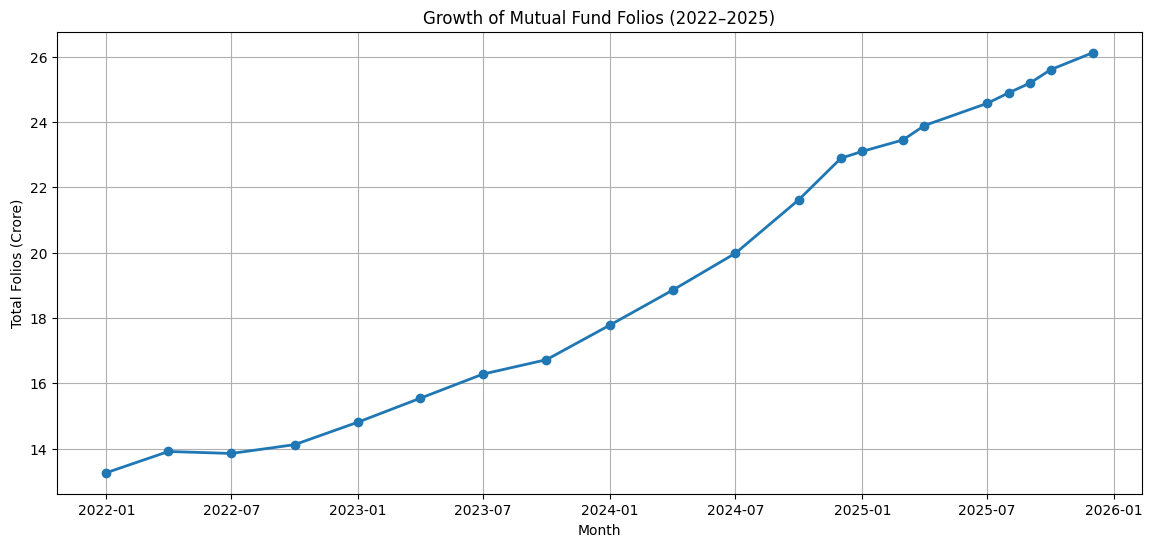

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.plot(
    folio["month"],
    folio["total_folios_crore"],
    marker="o",
    linewidth=2
)

plt.title("Growth of Mutual Fund Folios (2022–2025)")
plt.xlabel("Month")
plt.ylabel("Total Folios (Crore)")
plt.grid(True)

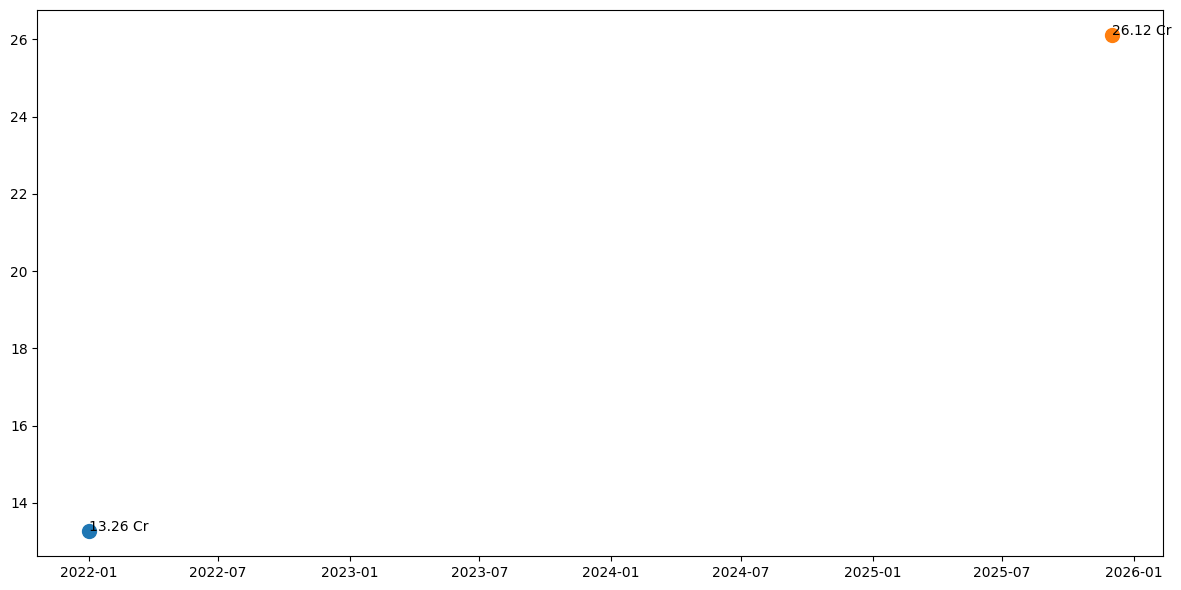

In [40]:
plt.scatter(
    folio["month"].iloc[0],
    folio["total_folios_crore"].iloc[0],
    s=100
)

plt.text(
    folio["month"].iloc[0],
    folio["total_folios_crore"].iloc[0],
    "13.26 Cr",
    fontsize=10
)

plt.scatter(
    folio["month"].iloc[-1],
    folio["total_folios_crore"].iloc[-1],
    s=100
)

plt.text(
    folio["month"].iloc[-1],
    folio["total_folios_crore"].iloc[-1],
    "26.12 Cr",
    fontsize=10
)

plt.tight_layout()

plt.savefig("../charts/folio_growth.png", dpi=300)

plt.show()

## Insight 10

The total number of mutual fund folios nearly doubled between January 2022 and December 2025, reflecting strong growth in retail investor participation.

In [41]:
print(nav.columns)

Index(['amfi_code', 'date', 'nav'], dtype='str')


In [42]:
print(portfolio.columns)

Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='str')


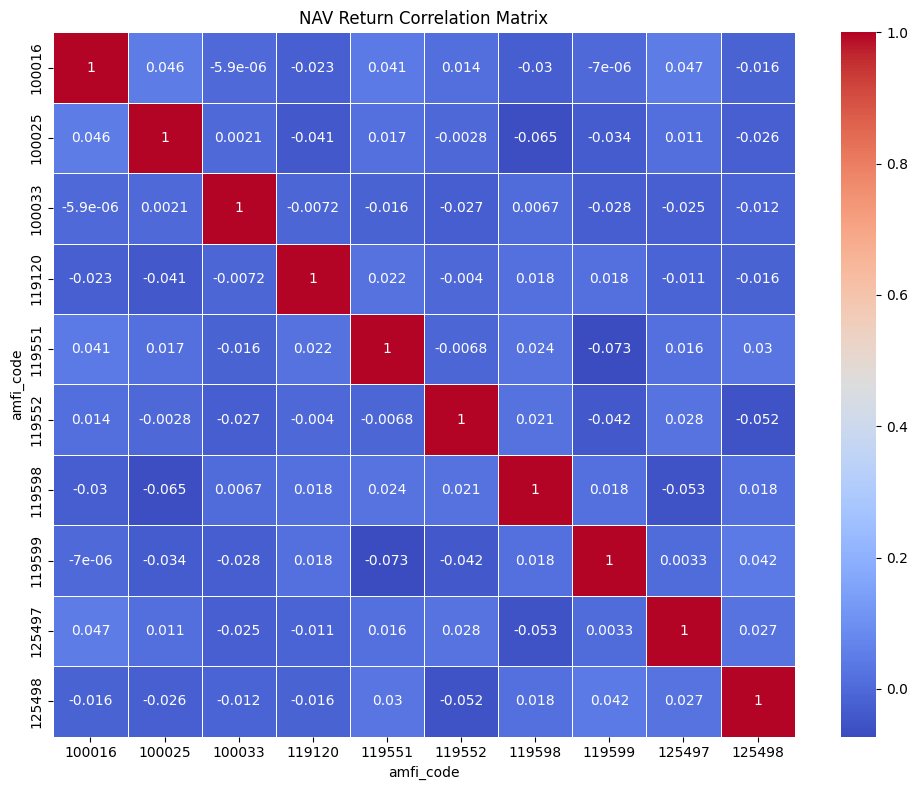

In [43]:
# Convert date column
nav["date"] = pd.to_datetime(nav["date"])

# Select first 10 funds
selected = nav["amfi_code"].unique()[:10]

nav10 = nav[nav["amfi_code"].isin(selected)]

# Create pivot table
pivot = nav10.pivot(index="date", columns="amfi_code", values="nav")

# Calculate daily returns
returns = pivot.pct_change()

# Correlation matrix
corr = returns.corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("NAV Return Correlation Matrix")

plt.tight_layout()

plt.savefig("../charts/nav_correlation.png", dpi=300)

plt.show()

## Insight 11

Most large-cap mutual funds show positive return correlations, indicating that they tend to move together under similar market conditions.

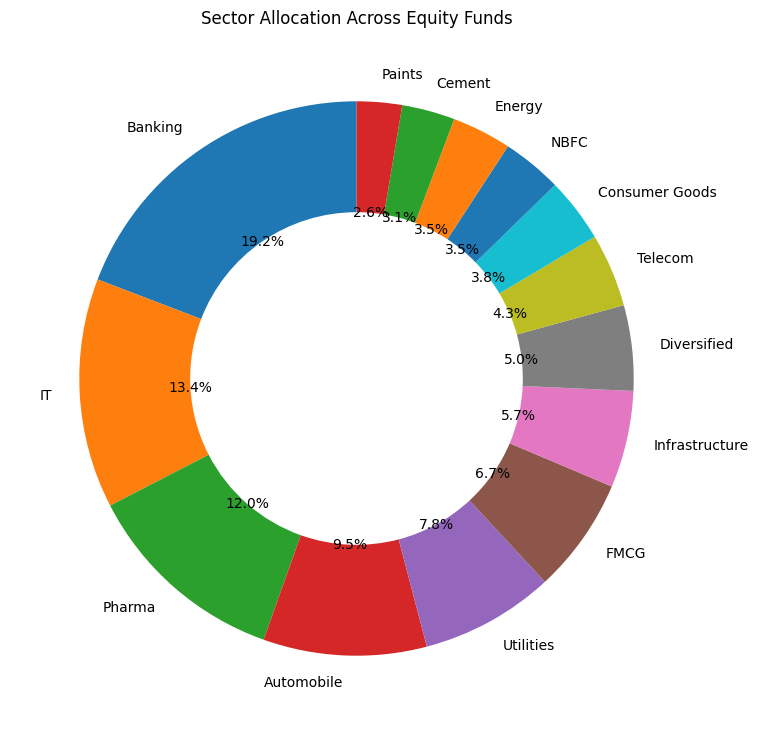

In [44]:
sector = portfolio.groupby("sector")["weight_pct"].sum().sort_values(ascending=False)

plt.figure(figsize=(9,9))

plt.pie(
    sector,
    labels=sector.index,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops=dict(width=0.4)
)

plt.title("Sector Allocation Across Equity Funds")

plt.savefig("../charts/sector_allocation_donut.png", dpi=300)

plt.show()

## Insight 12

The portfolio is diversified across multiple sectors, with a few sectors contributing the largest allocation, indicating concentration in key industries.

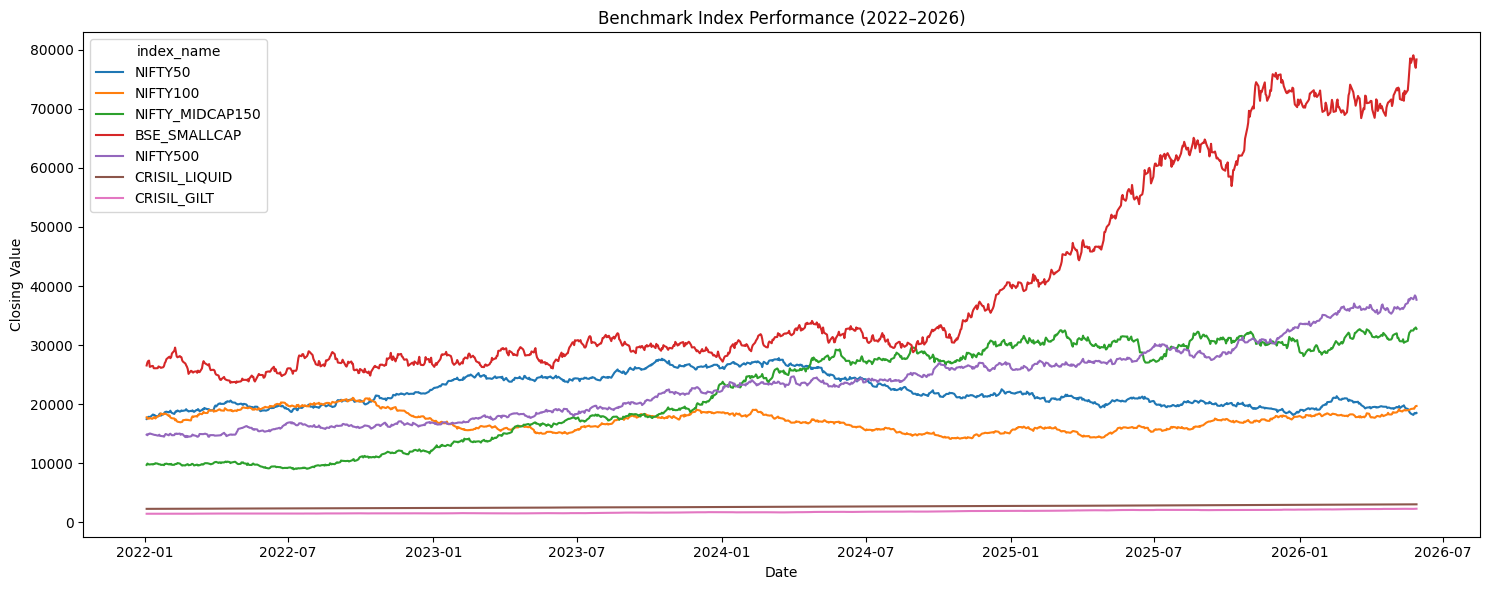

In [45]:
benchmark["date"] = pd.to_datetime(benchmark["date"])

plt.figure(figsize=(15,6))

sns.lineplot(
    data=benchmark,
    x="date",
    y="close_value",
    hue="index_name"
)

plt.title("Benchmark Index Performance (2022–2026)")
plt.xlabel("Date")
plt.ylabel("Closing Value")

plt.tight_layout()

plt.savefig("../charts/benchmark_trend.png", dpi=300)

plt.show()

## Insight 13

Benchmark indices showed an overall upward trend over the analysis period, reflecting long-term market growth despite short-term corrections.

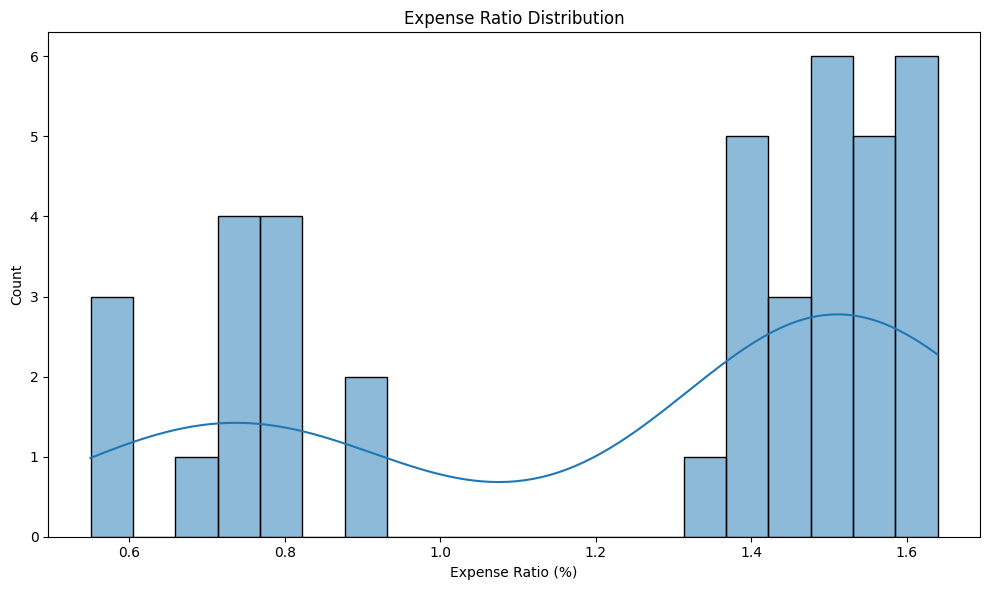

In [46]:
plt.figure(figsize=(10,6))

sns.histplot(
    performance["expense_ratio_pct"],
    bins=20,
    kde=True
)

plt.title("Expense Ratio Distribution")
plt.xlabel("Expense Ratio (%)")

plt.tight_layout()

plt.savefig("../charts/expense_ratio_distribution.png", dpi=300)

plt.show()

## Insight 14

Most mutual funds have expense ratios within the expected range, with relatively few high-expense schemes.

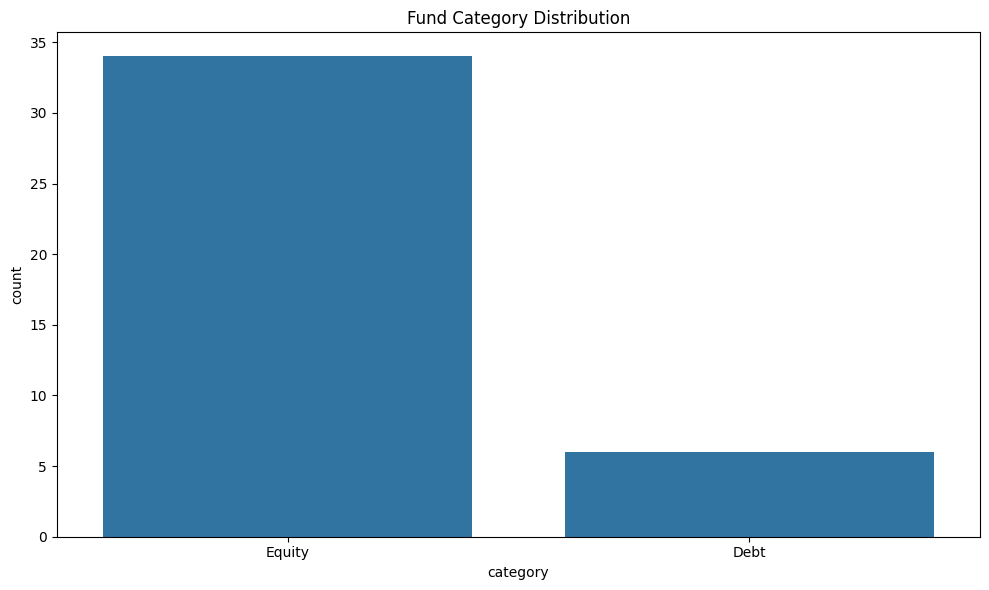

In [47]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=fund,
    x="category"
)

plt.title("Fund Category Distribution")

plt.tight_layout()

plt.savefig("../charts/fund_category_distribution.png", dpi=300)

plt.show()

## Insight 15

Equity funds represent the largest category in the dataset, highlighting their popularity compared to other fund types.

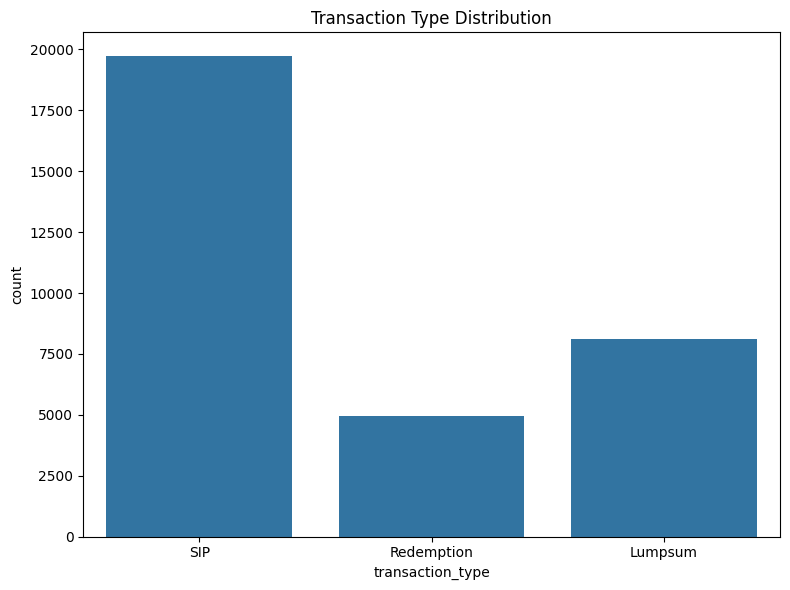

In [48]:
plt.figure(figsize=(8,6))

sns.countplot(
    data=transactions,
    x="transaction_type"
)

plt.title("Transaction Type Distribution")

plt.tight_layout()

plt.savefig("../charts/transaction_type_distribution.png", dpi=300)

plt.show()